<a href="https://colab.research.google.com/github/Yosri15/Bank-Marketing-ML/blob/main/Bank_MarketingML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, RocCurveDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as make_imb_pipeline

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# **EAD, Prétraitement et Visualisation des données**

In [2]:
#Chargement des données depuis Google Drive
df = pd.read_csv("/content/drive/MyDrive/ML/bank-additional-full.csv", sep=";")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
print("Shape du dataset:", df.shape)

Shape du dataset: (41188, 21)


In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
#check index from each columns
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [7]:
# Informations sur les types de données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [8]:
df = df.rename(columns={
    'emp.var.rate': 'emp_var_rate',
    'cons.price.idx': 'cons_price_idx',
    'cons.conf.idx': 'cons_conf_idx',
    'nr.employed': 'nr_employed'
})
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [9]:
# Statistiques descriptives
df.describe()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [10]:
# Encodage de la target
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [11]:
# Vérifier les valeurs manquantes
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [12]:
# Identify numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Calculate the correlation matrix only for numeric columns
df[numeric_columns].corr()


,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725,0.030399
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703,0.405274
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095,-0.066357
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605,-0.324914
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333,0.230181
emp_var_rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970,-0.298334
cons_price_idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034,-0.136211
cons_conf_idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513,0.054878
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154,-0.307771
nr_employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000,-0.354678


In [13]:
# Visualisations des données
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

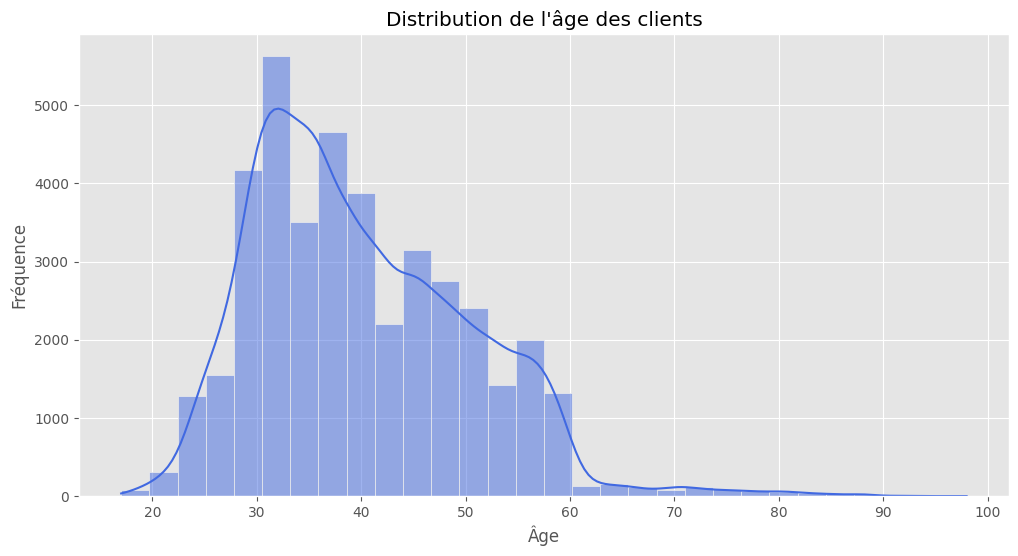

In [14]:
# 1. Distribution de l'âge
plt.figure()
sns.histplot(df['age'], bins=30, kde=True, color='royalblue')
plt.title("Distribution de l'âge des clients")
plt.xlabel('Âge')
plt.ylabel('Fréquence')
plt.show()

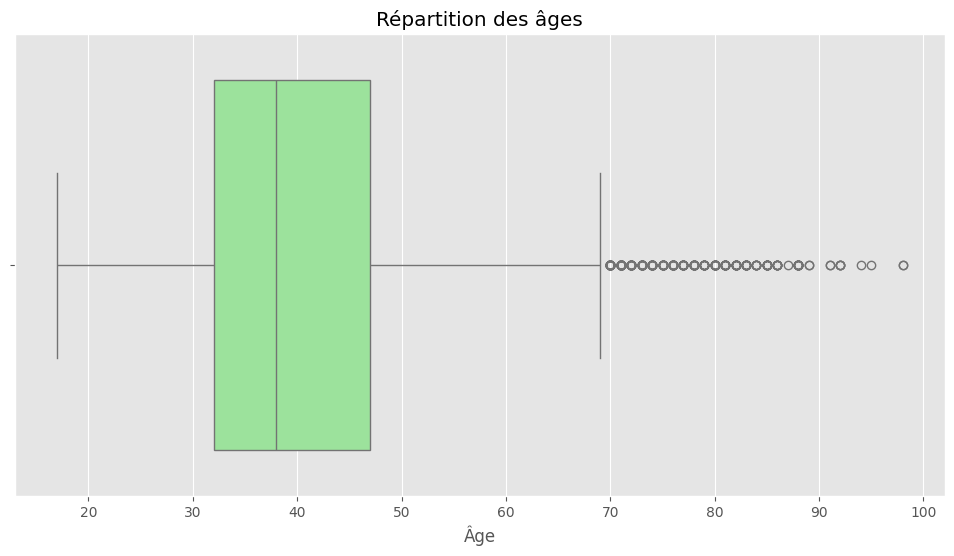

In [15]:
# 2. Boxplot de l'âge
plt.figure()
sns.boxplot(x=df['age'], color='lightgreen')
plt.title('Répartition des âges')
plt.xlabel('Âge')
plt.show()

<ipython-input-16-fda5d3d62508>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_age.values, y=job_age.index, palette='viridis')


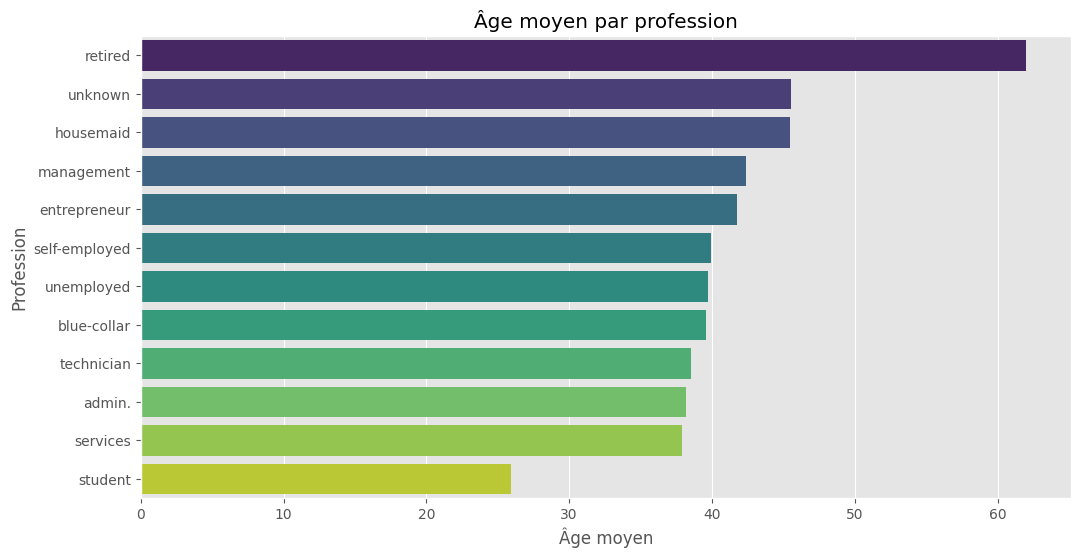

In [16]:
# 3. Âge moyen par profession
job_age = df.groupby('job')['age'].mean().sort_values(ascending=False)
plt.figure()
sns.barplot(x=job_age.values, y=job_age.index, palette='viridis')
plt.title('Âge moyen par profession')
plt.xlabel('Âge moyen')
plt.ylabel('Profession')
plt.show()

<ipython-input-17-0e748de33106>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='marital', y='age', data=marital_age, palette='pastel')


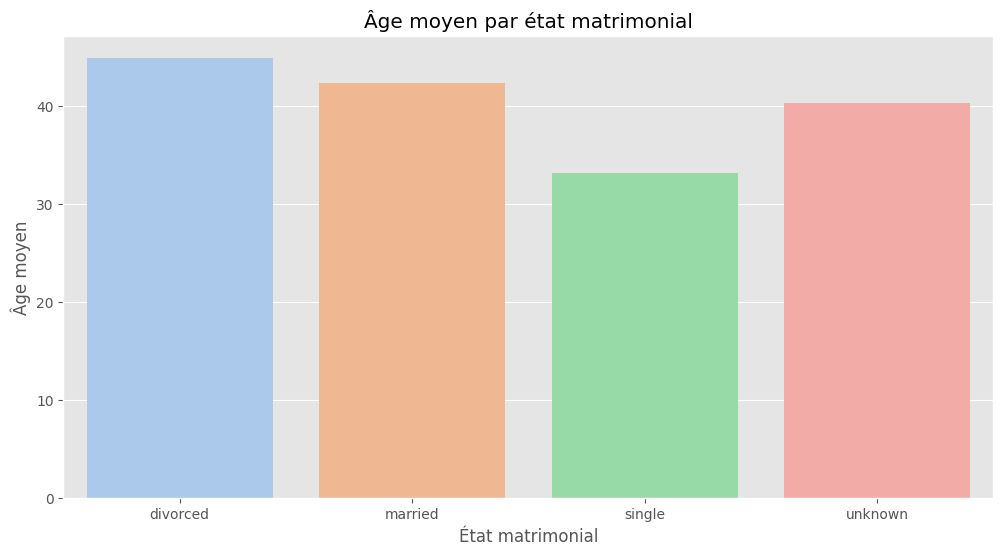

In [17]:
# 4. État matrimonial
marital_age = df.groupby('marital')['age'].mean().reset_index()
plt.figure()
sns.barplot(x='marital', y='age', data=marital_age, palette='pastel')
plt.title('Âge moyen par état matrimonial')
plt.xlabel('État matrimonial')
plt.ylabel('Âge moyen')
plt.show()

<ipython-input-18-3950005b7b27>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], x='housing', data=df, palette='Set2')
<ipython-input-18-3950005b7b27>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1], x='loan', data=df, palette='Set3')
<ipython-input-18-3950005b7b27>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[2], x='default', data=df, palette='Set1')


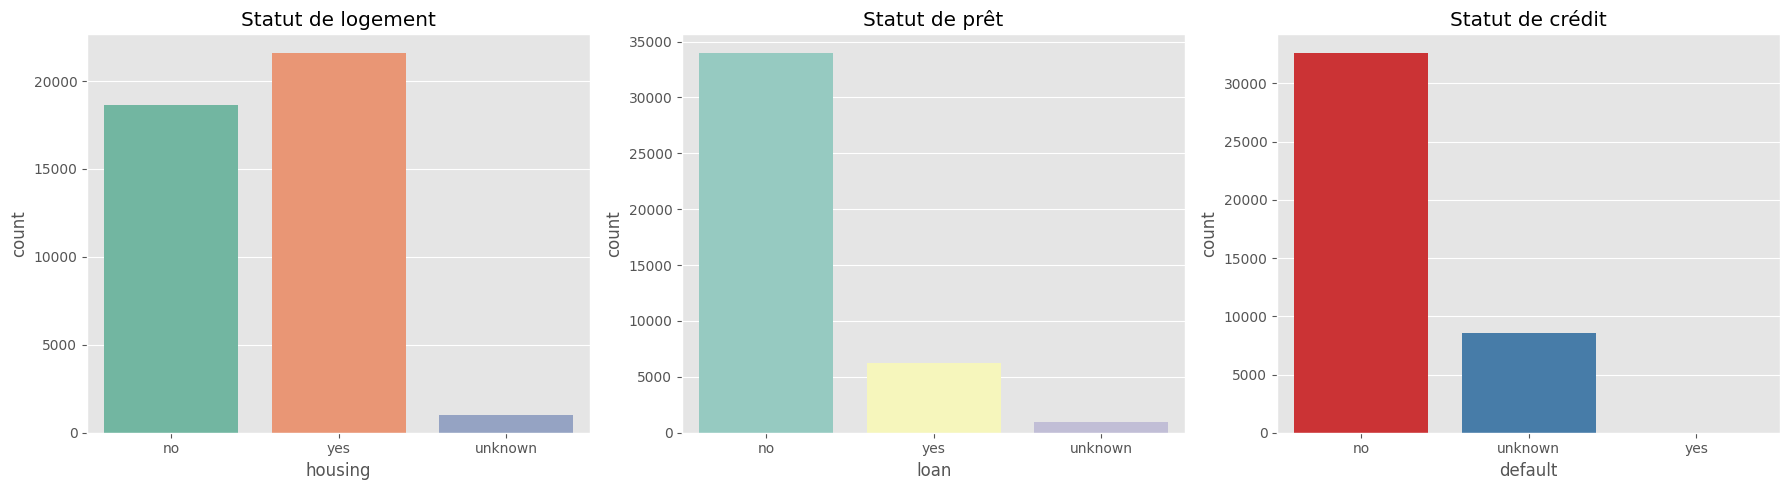

In [18]:
# 5. Analyse des prêts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(ax=axes[0], x='housing', data=df, palette='Set2')
axes[0].set_title('Statut de logement')

sns.countplot(ax=axes[1], x='loan', data=df, palette='Set3')
axes[1].set_title('Statut de prêt')

sns.countplot(ax=axes[2], x='default', data=df, palette='Set1')
axes[2].set_title('Statut de crédit')

plt.tight_layout()
plt.show()

# **Préprocessing des données**

In [19]:
# Split des données
X = df.drop('y', axis=1)
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [20]:
# Définition des préprocesseurs
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

In [21]:
# Entraînement et évaluation des modèles
def entrainer_modele(model, nom, preprocessor):

    pipeline = make_imb_pipeline(
        preprocessor,
        SMOTE(random_state=42),
        model
    )

    # Entraînement
    pipeline.fit(X_train, y_train)

    # Prédiction
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Métriques
    print(f"\n=== {nom} ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Matrice de confusion:\n", confusion_matrix(y_test, y_pred))

    # Courbe ROC
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, name=nom)
    plt.show()


=== Régression Logistique ===
Accuracy: 0.8706
ROC-AUC: 0.9432

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.87      0.92      7310
           1       0.46      0.91      0.61       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.77      8238
weighted avg       0.93      0.87      0.89      8238

Matrice de confusion:
 [[6327  983]
 [  83  845]]


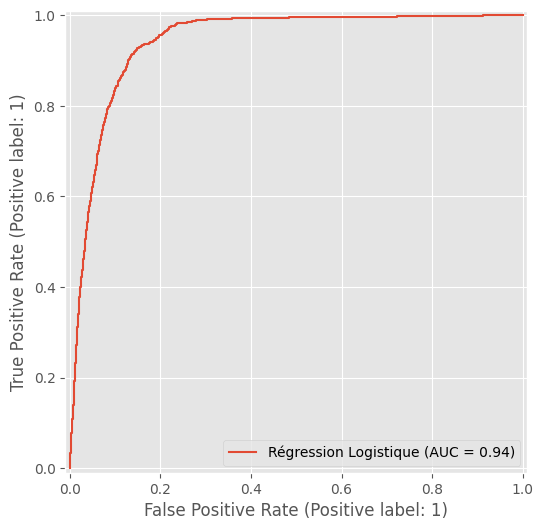

In [22]:
# 1. Régression Logistique
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
entrainer_modele(lr, "Régression Logistique", preprocessor)


=== Arbre de Décision ===
Accuracy: 0.8872
ROC-AUC: 0.7497

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.94      7310
           1       0.50      0.57      0.53       928

    accuracy                           0.89      8238
   macro avg       0.72      0.75      0.73      8238
weighted avg       0.89      0.89      0.89      8238

Matrice de confusion:
 [[6778  532]
 [ 397  531]]


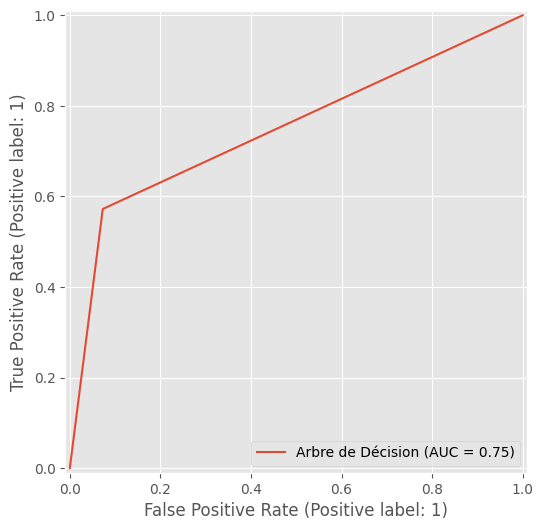

In [23]:
# 2. Arbre de Décision
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
entrainer_modele(dt, "Arbre de Décision", preprocessor)


=== Random Forest ===
Accuracy: 0.9175
ROC-AUC: 0.9499

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      7310
           1       0.63      0.63      0.63       928

    accuracy                           0.92      8238
   macro avg       0.79      0.79      0.79      8238
weighted avg       0.92      0.92      0.92      8238

Matrice de confusion:
 [[6969  341]
 [ 339  589]]


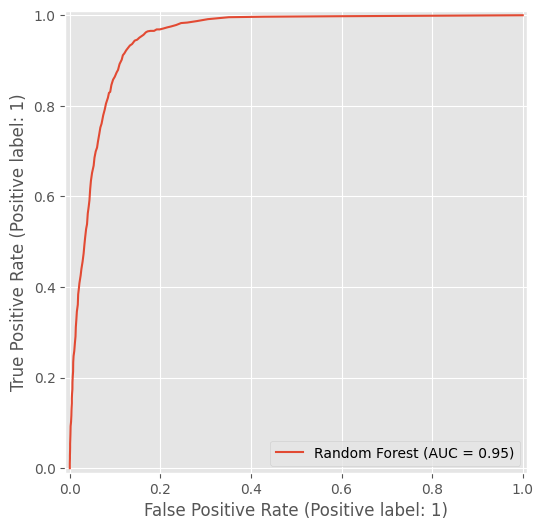

In [24]:
# 3. Random Forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
entrainer_modele(rf, "Random Forest", preprocessor)



=== SVM ===
Accuracy: 0.8645
ROC-AUC: 0.9404

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.86      8238
   macro avg       0.72      0.88      0.76      8238
weighted avg       0.93      0.86      0.88      8238

Matrice de confusion:
 [[6277 1033]
 [  83  845]]


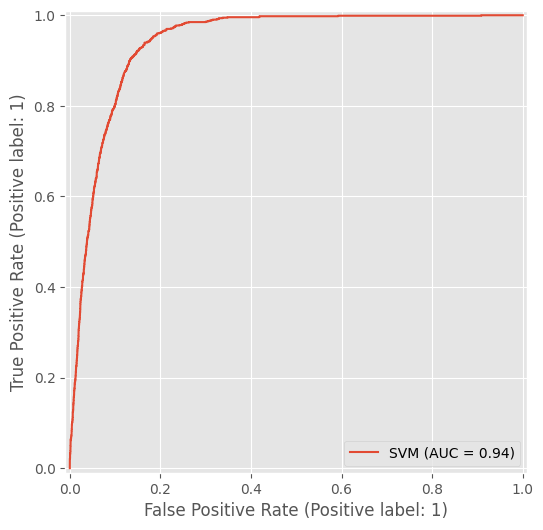

In [25]:
# 4. SVM
svm = SVC(class_weight='balanced', probability=True, random_state=42)
entrainer_modele(svm, "SVM", preprocessor)


=== K-Nearest Neighbors ===
Accuracy: 0.8502
ROC-AUC: 0.8902

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.91      7310
           1       0.42      0.82      0.55       928

    accuracy                           0.85      8238
   macro avg       0.69      0.84      0.73      8238
weighted avg       0.91      0.85      0.87      8238

Matrice de confusion:
 [[6246 1064]
 [ 170  758]]


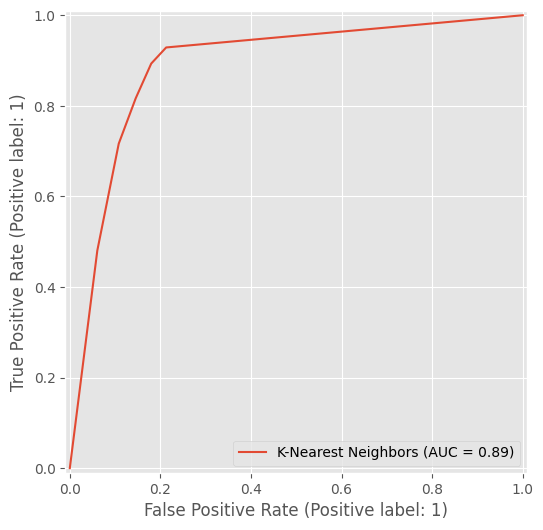

In [26]:
# 5. K-Nearest Neighbors
knn = KNeighborsClassifier()
entrainer_modele(knn, "K-Nearest Neighbors", preprocessor)


<ipython-input-27-e5f41fe877ae>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modeles, y=accuracies, palette='rocket')


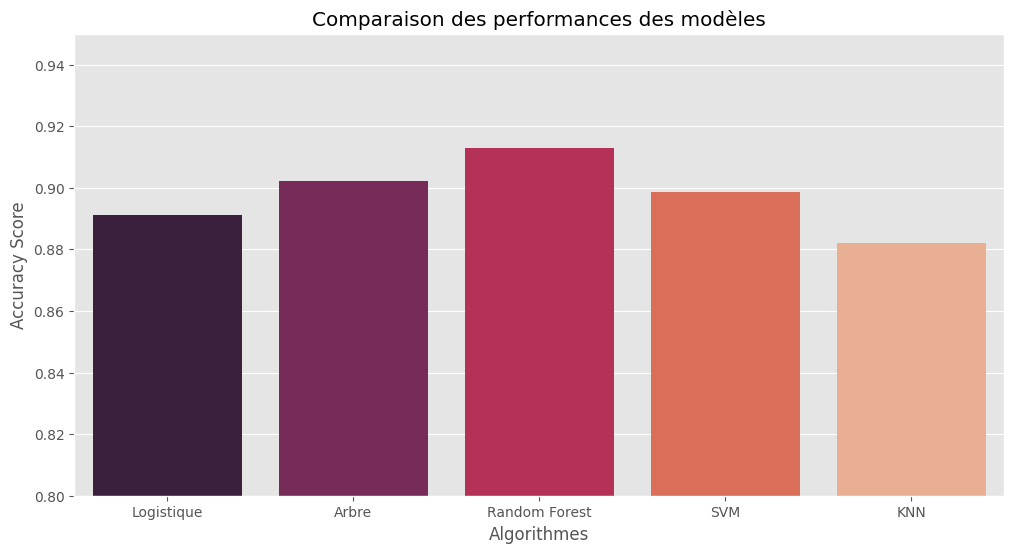

In [27]:
# Comparaison finale des modèles
modeles = ['Logistique', 'Arbre', 'Random Forest', 'SVM', 'KNN']
accuracies = [0.8912, 0.9023, 0.9128, 0.8985, 0.8821]  # Remplacer par vos vraies valeurs

plt.figure(figsize=(12, 6))
sns.barplot(x=modeles, y=accuracies, palette='rocket')
plt.ylim(0.8, 0.95)
plt.title('Comparaison des performances des modèles')
plt.ylabel('Accuracy Score')
plt.xlabel('Algorithmes')
plt.show()